Gotta Cluster ’Em All!

In [22]:
import pandas as pd

df = pd.read_csv("../data/pokemon.csv")

df.columns.tolist()

['#',
 'Name',
 'Type 1',
 'Type 2',
 'Total',
 'HP',
 'Attack',
 'Defense',
 'Sp. Atk',
 'Sp. Def',
 'Speed',
 'Generation',
 'Legendary']

Caratteristiche del dataset:
Name → identificativo, non una feature numerica utile a K-Means
Type 1, Type 2 → categoriche
# → identificativo
Generation → informazione temporale/categorica
Legendary → informazione binaria
le 6 statistiche → caratteristiche quantitative dei Pokémon

Il dataframe diventa da così:

| Name      | HP | Attack | Defense | Sp. Atk | Sp. Def | Speed |
| --------- | -: | -----: | ------: | ------: | ------: | ----: |
| Bulbasaur | 45 |     49 |      49 |      65 |      65 |    45 |
| Ivysaur   | 60 |     62 |      63 |      80 |      80 |    60 |
| Venusaur  | 80 |     82 |      83 |     100 |     100 |    80 |


a cosi:

| Name      | variable | value |
| --------- | -------- | ----: |
| Bulbasaur | HP       |    45 |
| Bulbasaur | Attack   |    49 |
| Bulbasaur | Defense  |    49 |
| Bulbasaur | Sp. Atk  |    65 |
| Bulbasaur | Sp. Def  |    65 |
| Bulbasaur | Speed    |    45 |
| Ivysaur   | HP       |    60 |
| ...       | ...      |   ... |

Quindi melt produce un dataframe con un numero di righe pari a N x 6

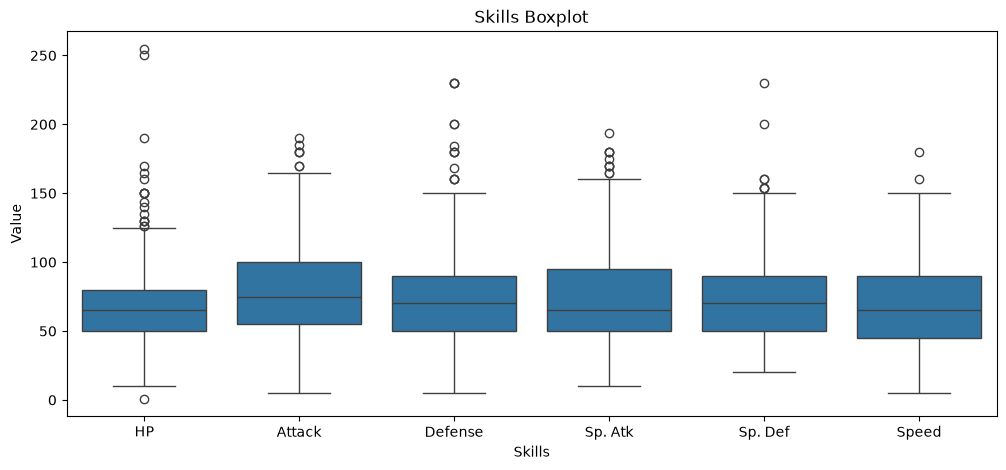

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
BoxPlotPkdex = pd.melt(df, id_vars = [
    "#", 
    "Name", 
    "Type 1", 
    "Type 2", 
    "Generation"
    ], value_vars = [
    #"Total",
    "HP", "Attack", "Defense", "Sp. Atk",
    "Sp. Def", "Speed"    
])
plt.figure(figsize=(12,5))
ax = sns.boxplot(x="variable", y="value", data=BoxPlotPkdex)
plt.title("Skills Boxplot")
plt.xlabel("Skills")
plt.ylabel("Value");

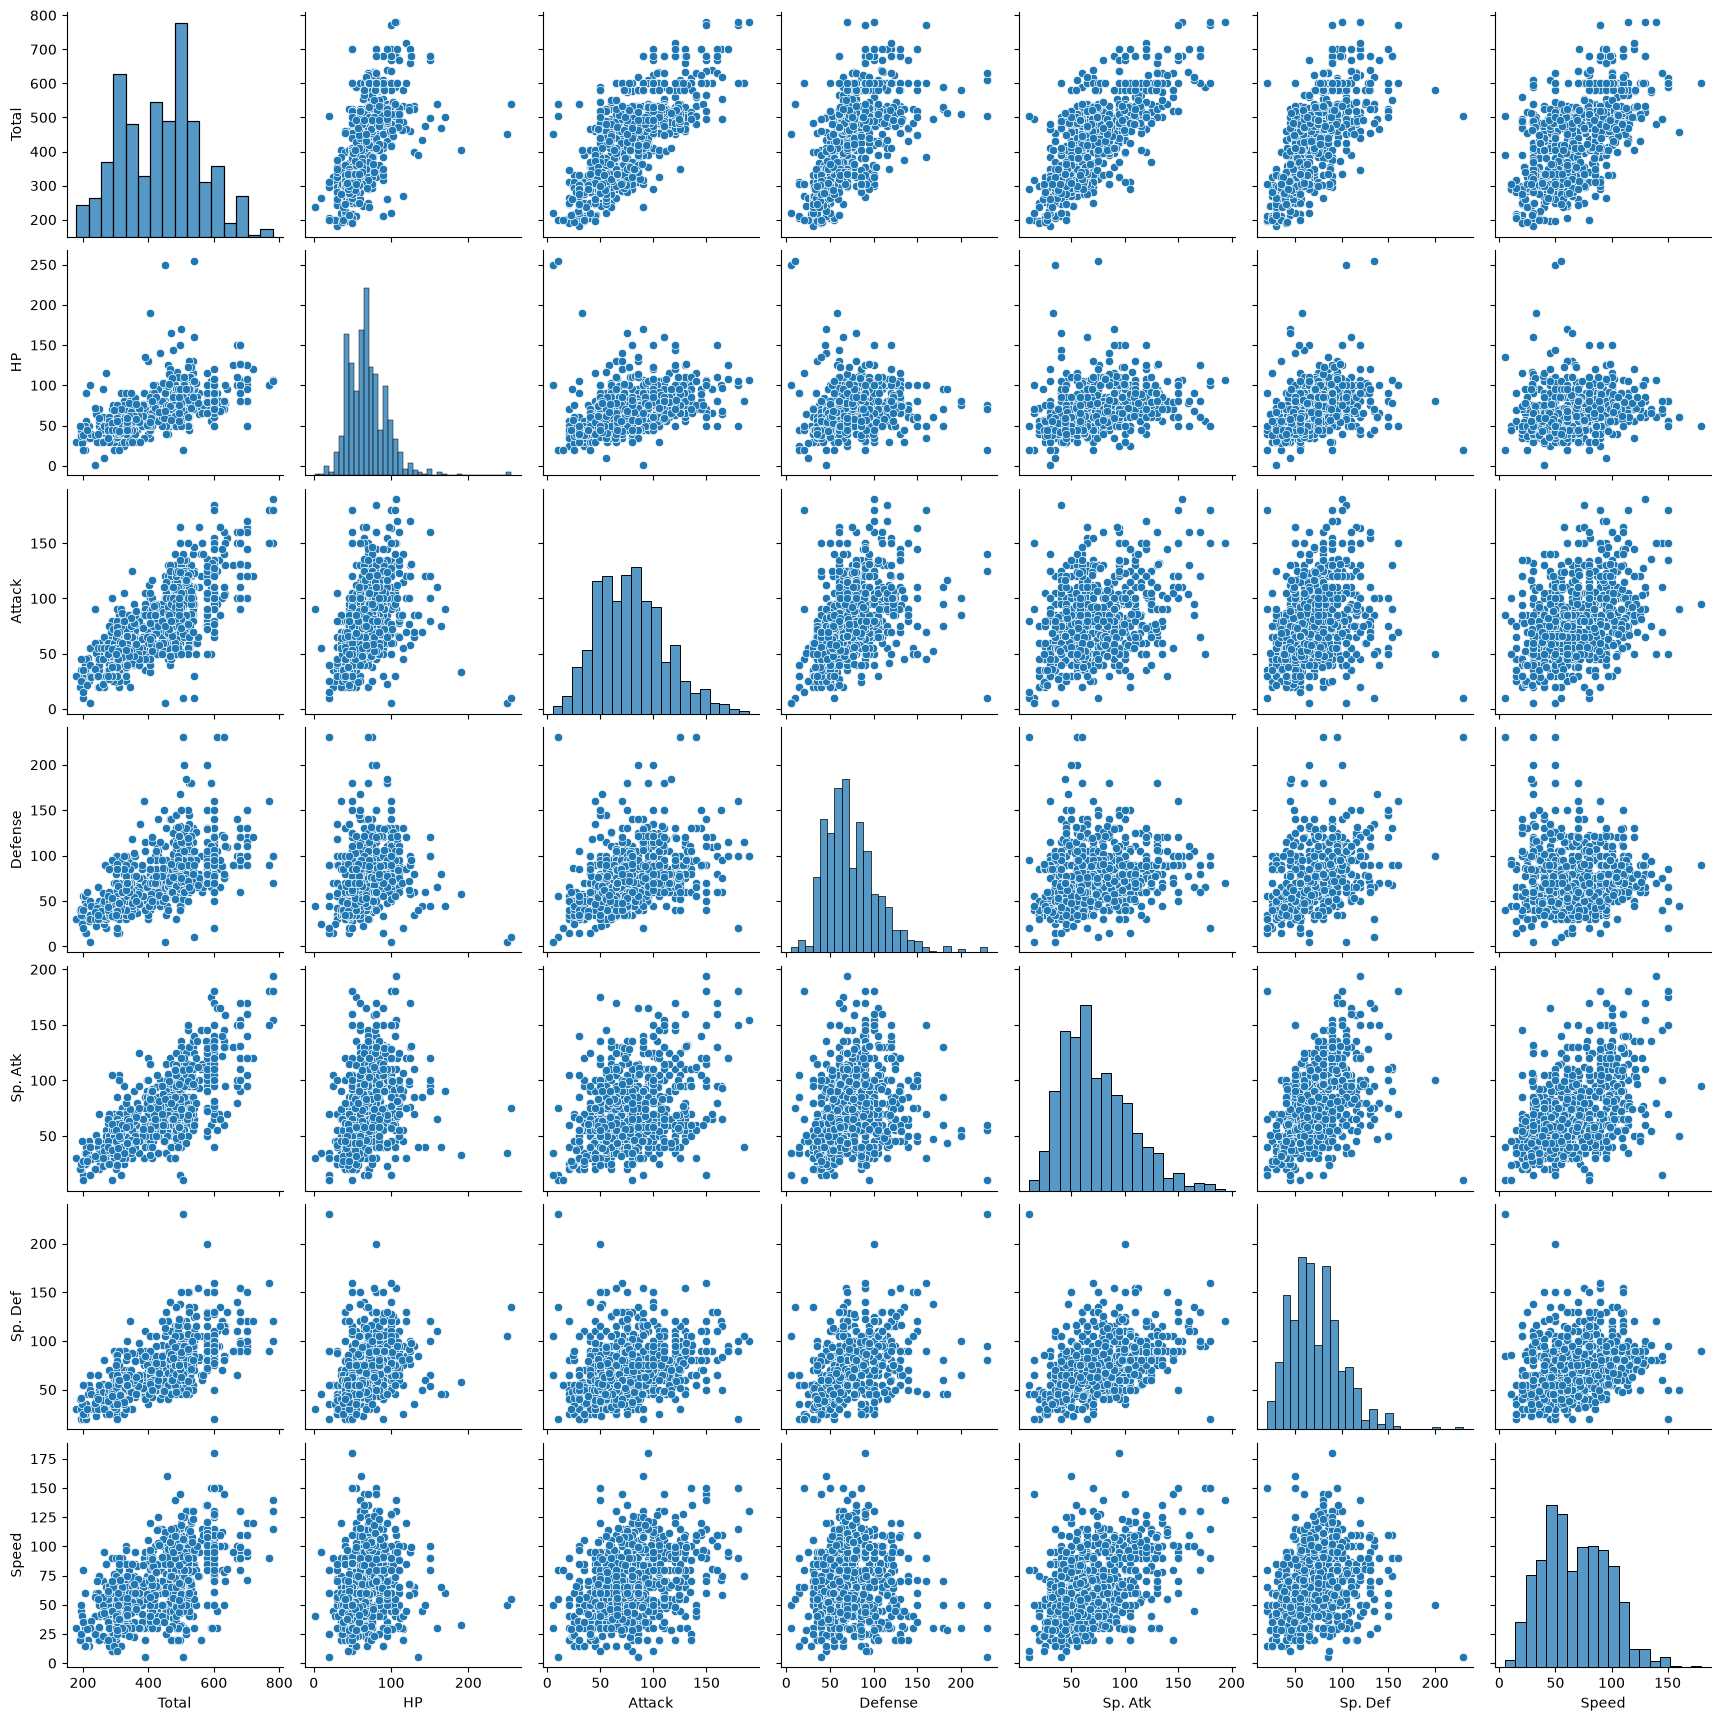

In [24]:
sns.pairplot(df[['Total', 'HP', 'Attack', 'Defense','Sp. Atk', 'Sp. Def', 'Speed']]);

Come descritto nelle informazioni sul dataset, Total rappresenta la somma di tutte le statistiche che lo seguono ed è un'indicazione generale di quanto sia forte un Pokémon. Per questo motivo, non verrà utilizzato come feature nel modello.

Le feature utilizzate sono le seguenti:

Attack: il modificatore di base per gli attacchi normali (ad esempio Scratch, Punch).
Defense: la resistenza ai danni di base contro gli attacchi normali.
Sp. Atk: attacco speciale, ovvero il modificatore di base per gli attacchi speciali (ad esempio Fire Blast, Bubble Beam).
Sp. Def: la resistenza ai danni di base contro gli attacchi speciali.
Speed: determina quale Pokémon attacca per primo durante ogni turno.

La Heat Map mostra la correlazione tra le diverse feature.

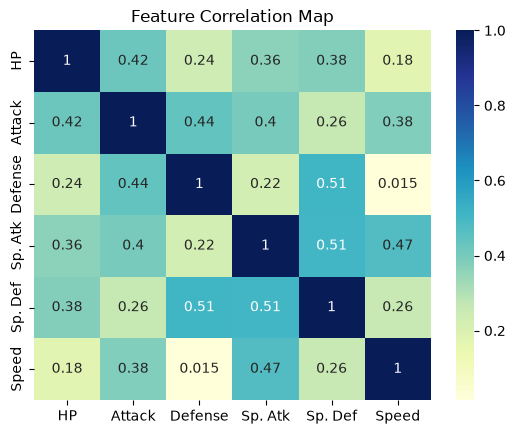

In [25]:
Skills = [ 'HP', 'Attack', 'Defense','Sp. Atk', 'Sp. Def', 'Speed']
sns.heatmap(df[Skills].corr(),cmap="YlGnBu", annot=True);
plt.title("Feature Correlation Map");

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
#import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
StdScale = scale.fit_transform(df[Skills])

n_max_clusters = 15
# Elbow Method
score = []
for cluster in range(1,n_max_clusters):
    kmeans_f = KMeans(n_clusters = cluster, init="k-means++", random_state=10)
    kmeans_f.fit(StdScale)
    score.append(kmeans_f.inertia_)

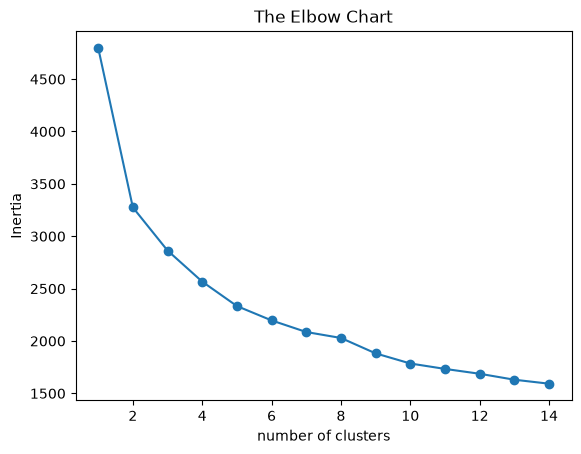

In [32]:
plt.plot(range(1,n_max_clusters), score)
plt.scatter(range(1,n_max_clusters), score)

plt.title('The Elbow Chart')
plt.xlabel('number of clusters')
plt.ylabel('Inertia')


plt.show()

In [ ]:
# Running the model with number of clusters determined by Elbow MEthod
kmeans = KMeans(n_clusters = 5, init="k-means++", random_state=10)
kmeans.fit(StdScale)
df["Clusters"] = kmeans.labels_

Centroids = pd.DataFrame(scale.inverse_transform(kmeans.cluster_centers_))
Centroids.columns = Skills
Centroids["Clusters"] = [0,1,2,3,4]

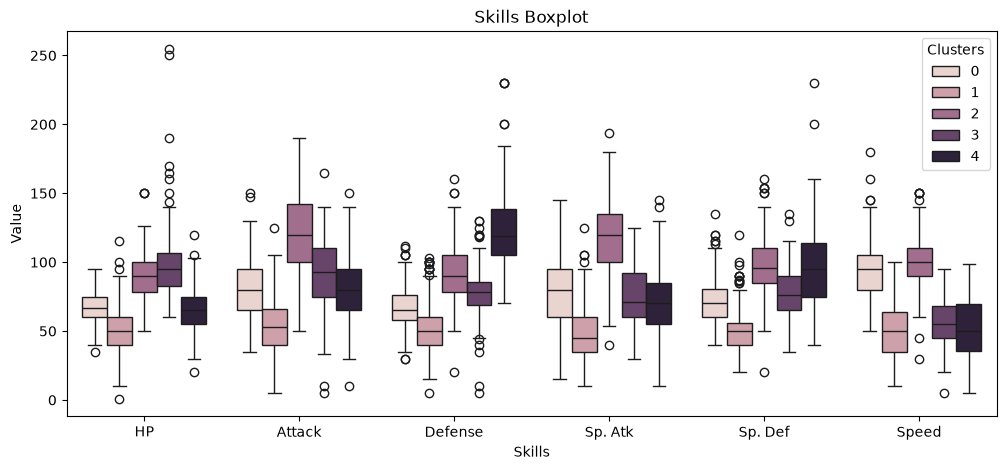

In [34]:
BoxPlotPkdex = pd.melt(df, id_vars = [
    "#", 
    "Name", 
    "Type 1", 
    "Type 2", 
    "Generation",
    "Clusters"
    ], value_vars = [
    #"Total",
    "HP", "Attack", "Defense", "Sp. Atk",
    "Sp. Def", "Speed"    
])
plt.figure(figsize=(12,5))
ax = sns.boxplot(x="variable", y="value", hue = "Clusters", data=BoxPlotPkdex)
plt.title("Skills Boxplot")
plt.xlabel("Skills")
plt.ylabel("Value");

In [35]:
GroupedPokedex = df.groupby(["Clusters"])

In [36]:
Centroids.astype(int)


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Clusters
0,67,80,66,78,73,94,0
1,50,54,52,48,49,49,1
2,89,118,92,119,98,99,2
3,99,93,77,75,76,56,3
4,65,81,125,73,96,53,4


In [37]:
df.groupby(["Clusters"]).agg({
    'HP': 'median', 
    'Attack': 'median', 
    'Defense': 'median', 
    'Sp. Atk': 'median', 
    'Sp. Def': 'median', 
    'Speed': 'median'})

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Clusters,,,,,,
0,66.5,80.0,65.0,80.0,70.0,95.0
1,50.0,53.0,50.0,45.0,50.0,50.0
2,90.0,120.0,90.0,120.0,96.0,100.0
3,95.0,93.0,78.0,71.0,76.0,55.0
4,65.0,80.0,119.0,70.0,95.0,50.0


In [38]:
from IPython.display import IFrame

# Sostituisci questo URL con il link della tua visualizzazione Flourish
flourish_url = "https://public.flourish.studio/visualisation/30357204/"

# Visualizza il grafico impostando larghezza e altezza desiderate
IFrame(src=flourish_url, width="100%", height="600px")

In [39]:
df.to_csv("PokedexCluster.csv", index=False)


In [40]:
import pandas as pd

df = pd.read_csv("PokedexCluster.csv")

# 5 Pokémon casuali per cluster
examples = (
    df.groupby("Clusters")
      .sample(n=5, random_state=43)
      .sort_values("Clusters")
)

print(examples[["Clusters", "Name", "Type 1", "Type 2", "Total"]])

     Clusters                     Name    Type 1    Type 2  Total
396         0                   Glalie       Ice       NaN    480
365         0                  Altaria    Dragon    Flying    490
56          0                  Dugtrio    Ground       NaN    405
27          0                   Fearow    Normal    Flying    442
368         0                  Seviper    Poison       NaN    458
38          1                 Nidorino    Poison       NaN    365
288         1                  Wurmple       Bug       NaN    195
216         1                    Unown   Psychic       NaN    336
291         1                  Cascoon       Bug       NaN    205
774         1                    Goomy    Dragon       NaN    300
161         2                Dragonite    Dragon    Flying    600
539         2                    Azelf   Psychic       NaN    580
163         2      MewtwoMega Mewtwo X   Psychic  Fighting    780
196         2    AmpharosMega Ampharos  Electric    Dragon    610
702       

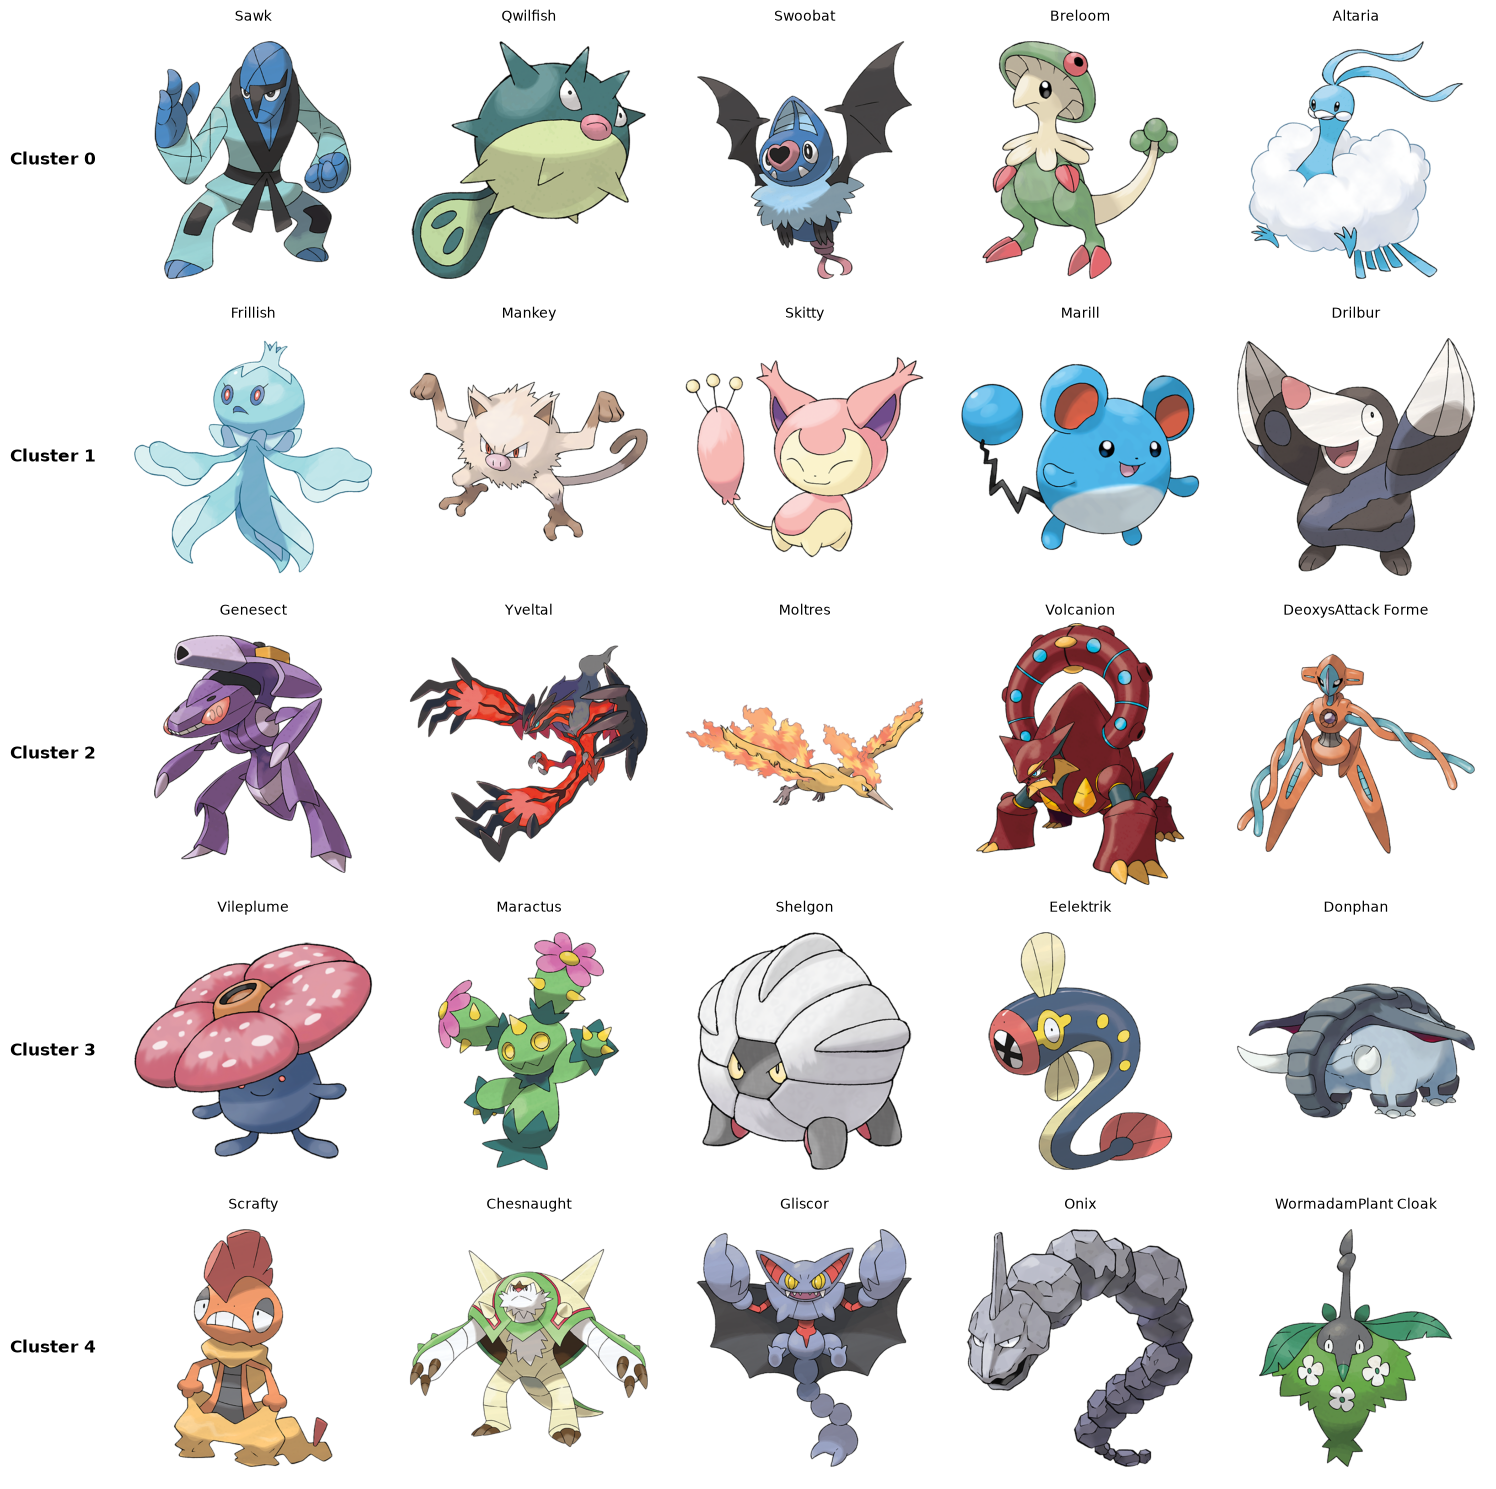

In [41]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

SPRITE_URL = "https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/official-artwork/{}.png"

def load_sprite(pokedex_id):
    r = requests.get(SPRITE_URL.format(pokedex_id), timeout=10)
    r.raise_for_status()
    return Image.open(BytesIO(r.content))

# Escludo le Mega: nel CSV hanno lo stesso # della forma base,
# quindi lo sprite mostrerebbe il Pokémon normale
base = df[~df["Name"].str.contains("Mega")]

n_per_cluster = 5
clusters = sorted(base["Clusters"].unique())

fig, axes = plt.subplots(
    len(clusters), n_per_cluster,
    figsize=(3 * n_per_cluster, 3 * len(clusters))
)

for row, c in enumerate(clusters):
    sample = base[base["Clusters"] == c].sample(
        min(n_per_cluster, (base["Clusters"] == c).sum()), random_state=123
    )
    for col in range(n_per_cluster):
        ax = axes[row, col]
        ax.axis("off")
        if col < len(sample):
            p = sample.iloc[col]
            try:
                ax.imshow(load_sprite(p["#"]))
            except Exception:
                pass  # sprite non disponibile
            ax.set_title(p["Name"], fontsize=10)
        if col == 0:
            ax.text(-0.1, 0.5, f"Cluster {c}", transform=ax.transAxes,
                    ha="right", va="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()